In [1]:
!sudo apt-get update
!sudo apt-get install iverilog -y
!pip install pyverilog ply jinja2 torch_geometric transformers scikit-learn matplotlib

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,533 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main 

In [2]:
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import Dataset
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader
from transformers import AutoModel, AutoConfig, AutoTokenizer
from pyverilog.dataflow.dataflow_analyzer import VerilogDataflowAnalyzer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

class FeatureMLP(nn.Module):
    def __init__(self, num_manual_features: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(num_manual_features),
            nn.Linear(num_manual_features, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim)
        )
    def forward(self, x):
        return self.net(x)

from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool

from torch_geometric.nn import GATv2Conv

from torch_geometric.nn import GATv2Conv

class StructuralGNN(nn.Module):
    def __init__(self, num_node_features: int, hidden_channels: int):
        super().__init__()
        self.conv1 = GATv2Conv(num_node_features, hidden_channels, heads=4, concat=True)
        self.conv2 = GATv2Conv(hidden_channels * 4, hidden_channels, heads=4, concat=False)
        self.norm = nn.LayerNorm(hidden_channels)

    def forward(self, x, edge_index, batch):
        x = F.elu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        x = self.norm(x)
        return torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)

class SemanticTransformer(nn.Module):
    def __init__(self, model_name: str = "prajjwal1/bert-tiny"):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.transformer = AutoModel.from_pretrained(model_name)
    def forward(self, input_ids, attention_mask):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state[:, 0, :]


class TriModalTrojanDetector(nn.Module):
    def __init__(self, manual_feat_dim, num_node_feat, gnn_hidden_dim, fusion_dim=512):
        super(TriModalTrojanDetector, self).__init__()

        self.feature_branch = nn.Sequential(
            nn.Linear(manual_feat_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64)
        )

        self.gnn_branch = StructuralGNN(num_node_features=num_node_feat, hidden_channels=gnn_hidden_dim)

        self.transformer_name = "microsoft/codebert-base"
        self.semantic_branch = AutoModel.from_pretrained(self.transformer_name)

        for param in self.semantic_branch.parameters():
            param.requires_grad = False

        codebert_out_dim = 768

        total_concat_dim = 64 + (gnn_hidden_dim * 2) + codebert_out_dim

        self.classifier = nn.Sequential(
            nn.BatchNorm1d(total_concat_dim),
            nn.Linear(total_concat_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(fusion_dim, 2)
        )

    def forward(self, batch):
        feat_emb = self.feature_branch(batch.manual_features.view(batch.num_graphs, -1))

        struct_emb = self.gnn_branch(batch.x, batch.edge_index, batch.batch)

        transformer_out = self.semantic_branch(
            batch.input_ids.view(batch.num_graphs, -1),
            batch.attention_mask.view(batch.num_graphs, -1)
        )
        sem_emb = transformer_out.last_hidden_state[:, 0, :]

        fused_vector = torch.cat([feat_emb, struct_emb, sem_emb], dim=1)
        return self.classifier(fused_vector)

In [ ]:
import re
import torch
from pyverilog.dataflow.dataflow_analyzer import VerilogDataflowAnalyzer

class EnhancedVerilogParser:
    def __init__(self, filepath):
        self.filepath = filepath
        with open(filepath, 'r') as f:
            self.raw_code = f.read()

    def get_semantic_text(self):
        code = re.sub(r'//.*', '', self.raw_code)
        code = re.sub(r'/\*.*?\*/', '', code, flags=re.DOTALL)
        return re.sub(r'\s+', ' ', code).strip()

    def get_manual_features(self):
        num_assigns = len(re.findall(r'\bassign\b', self.raw_code))
        num_always = len(re.findall(r'\balways\b', self.raw_code))
        logic_ops = len(re.findall(r'(&&|\|\||==|!=)', self.raw_code))


        return torch.tensor([[num_assigns, num_always, logic_ops]], dtype=torch.float)


    def get_structural_graph(self):
        try:
            match = re.search(r'\bmodule\s+(\w+)', self.raw_code)
            top_mod_name = match.group(1) if match else 'TOP'

            analyzer = VerilogDataflowAnalyzer([self.filepath], topmodule=top_mod_name)
            analyzer.generate()
            binddict = analyzer.getBinddict()

            edges_src, edges_dst = [], []
            node_to_id, node_roles = {}, {}
            current_id = 0

            inputs = set(re.findall(r'\binput\s+(?:\[[^\]]*\]\s*)?([^,; \n]+)', self.raw_code))
            outputs = set(re.findall(r'\boutput\s+(?:\[[^\]]*\]\s*)?([^,; \n]+)', self.raw_code))

            for target_var, bind_list in binddict.items():
                t_name = str(target_var)
                if t_name not in node_to_id:
                    node_to_id[t_name] = current_id
                    node_roles[current_id] = [0.0, 1.0, 0.0] if t_name in outputs else [0.0, 0.0, 1.0]
                    current_id += 1

                t_id = node_to_id[t_name]
                for bind in bind_list:
                    for src_var in bind.tocode().split():
                        if src_var.replace('_', '').isalnum() and not src_var.isdigit():
                            if src_var not in node_to_id:
                                node_to_id[src_var] = current_id
                                node_roles[current_id] = [1.0, 0.0, 0.0] if src_var in inputs else [0.0, 0.0, 1.0]
                                current_id += 1
                            edges_src.append(node_to_id[src_var])
                            edges_dst.append(t_id)

            edge_index = torch.tensor([edges_src, edges_dst], dtype=torch.long)
            num_nodes = max(len(node_to_id), 1)

            graph_x = torch.zeros((num_nodes, 3), dtype=torch.float)
            for i, role in node_roles.items():
                graph_x[i] = torch.tensor(role)

            if edge_index.shape[1] == 0:
                return torch.zeros((1, 3)), torch.empty((2, 0), dtype=torch.long)

            return graph_x, edge_index
        except Exception:
            return torch.zeros((1, 3)), torch.empty((2, 0), dtype=torch.long)

In [5]:


NUM_MANUAL = 3
NUM_NODE_FEAT = 3
GNN_HIDDEN = 64
TRANSFORMER_NAME = "prajjwal1/bert-tiny"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TriModalTrojanDetector(NUM_MANUAL, NUM_NODE_FEAT, GNN_HIDDEN).to(device)
print("✅ Integrated Tri-Modal Architecture Ready.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

✅ Integrated Tri-Modal Architecture Ready.


In [13]:
import os
import random
import pandas as pd

def get_rnd():
    return "".join(random.choice("abcdefghijklmnopqrstuvwxyz") for _ in range(4))


def add_junk_code(code):
    """
    Inserts harmless 'dead code' into the module.
    This forces the model to learn logic patterns rather than just
    flagging modules that have 'extra' lines.
    """
    junk_signals = [
        f"    wire junk_{get_rnd()};",
        f"    assign junk_{get_rnd()} = 1'b0;",
        f"    wire [3:0] debug_bus_{get_rnd()};",
        f"    assign debug_bus_{get_rnd()} = 4'b0000;"
    ]

    lines = code.split('\n')
    for _ in range(random.randint(1, 3)):
        lines.insert(-1, random.choice(junk_signals))
    return '\n'.join(lines)

def hw_alu(name, width, is_trojan):
    """Template 1: ALU with randomized bit-pattern triggers"""
    rand_trig_a = hex(random.randint(0, (2**width)-1))
    rand_trig_b = hex(random.randint(0, (2**width)-1))

    trig = f"assign result = (a == {width}'{rand_trig_a} && b == {width}'{rand_trig_b}) ? {width}'b0 : res_int;" if is_trojan else "assign result = res_int;"

    return f"""module {name}(input [{width-1}:0] a, b, input [2:0] op, output [{width-1}:0] result);
    reg [{width-1}:0] res_int;
    always @(*) begin
        case(op)
            3'b000: res_int = a + b;
            3'b001: res_int = a - b;
            3'b010: res_int = a & b;
            3'b011: res_int = a | b;
            3'b100: res_int = a ^ b;
            3'b101: res_int = a << 1;
            3'b110: res_int = a >> 1;
            default: res_int = {width}'b0;
        endcase
    end
    {trig}
endmodule"""

def hw_fifo(name, width, is_trojan):
    """Template 2: Synchronous FIFO"""
    depth_bits = random.choice([3, 4, 5])
    trig = "assign full = 1'b0;" if is_trojan else f"assign full = (count == {depth_bits+1}'d{2**depth_bits});"
    return f"""module {name}(input clk, rst, wr_en, rd_en, input [{width-1}:0] din, output reg [{width-1}:0] dout, output full, empty);
    reg [{width-1}:0] mem [0:{(2**depth_bits)-1}];
    reg [{depth_bits-1}:0] wr_ptr, rd_ptr;
    reg [{depth_bits}:0] count;
    always @(posedge clk) begin
        if (rst) begin wr_ptr <= 0; rd_ptr <= 0; count <= 0; end
        else begin
            if (wr_en && !full) begin mem[wr_ptr] <= din; wr_ptr <= wr_ptr + 1; count <= count + 1; end
            if (rd_en && !empty) begin dout <= mem[rd_ptr]; rd_ptr <= rd_ptr + 1; count <= count - 1; end
        end
    end
    assign empty = (count == 0);
    {trig}
endmodule"""

def hw_pwm(name, width, is_trojan):
    """Template 3: PWM with randomized duty-cycle trigger"""
    rand_thresh = int((2**width) * random.uniform(0.85, 0.99))
    trig = f"assign pwm_out = (duty > {width}'d{rand_thresh}) ? 1'b1 : pwm_int;" if is_trojan else "assign pwm_out = pwm_int;"

    return f"""module {name}(input clk, rst, input [{width-1}:0] duty, output pwm_out);
    reg [{width-1}:0] counter;
    reg pwm_int;
    always @(posedge clk) begin
        if (rst) counter <= 0;
        else counter <= counter + 1;
    end
    always @(*) begin
        if (counter < duty) pwm_int = 1'b1;
        else pwm_int = 1'b0;
    end
    {trig}
endmodule"""


def create_distinct_hardware_dataset(root="my_dataset", num_per_class=250):
    os.makedirs(f"{root}/clean", exist_ok=True)
    os.makedirs(f"{root}/trojan", exist_ok=True)
    data = []

    hw_pool = [hw_alu, hw_fifo, hw_pwm]
    bit_widths = [8, 16, 32, 64]

    for i in range(num_per_class):
        for is_trojan in [False, True]:
            folder = "trojan" if is_trojan else "clean"
            label = 1 if is_trojan else 0

            hw_template = random.choice(hw_pool)
            width = random.choice(bit_widths)

            mod_name = f"{hw_template.__name__}_{width}bit_{i}_{get_rnd()}"
            code = hw_template(mod_name, width, is_trojan)

            if not is_trojan:
                code = add_junk_code(code)

            filename = f"{folder}/{mod_name}.v"
            with open(f"{root}/{filename}", "w") as f:
                f.write(code)
            data.append([filename, label])

    pd.DataFrame(data, columns=["filename", "label"]).to_csv("metadata.csv", index=False)
    print(f"✅ Generated {num_per_class * 2} files with randomized triggers and junk code.")

!rm -rf my_dataset metadata.csv processed_dataset
create_distinct_hardware_dataset()

✅ Generated 500 files with randomized triggers and junk code.


In [ ]:
import os
import sys
from tqdm import tqdm
from torch_geometric.data import Data

PROCESSED_DIR = "processed_dataset"
os.makedirs(PROCESSED_DIR, exist_ok=True)

tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")

def preprocess_and_save_dataset(csv_file, root_dir, output_dir):
    df = pd.read_csv(csv_file)
    print(f"⏳ Pre-processing {len(df)} files. This takes a few minutes, but only happens once...")

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        filename = row.iloc[0]
        label = int(row.iloc[1])
        file_path = f"{root_dir}/{filename}"

        with open(os.devnull, 'w') as fnull:
            old_stdout, old_stderr = sys.stdout, sys.stderr
            sys.stdout, sys.stderr = fnull, fnull
            try:
                parser = EnhancedVerilogParser(file_path)
                text = parser.get_semantic_text()
                graph_x, edge_index = parser.get_structural_graph()
                manual_feat = parser.get_manual_features()
            finally:
                sys.stdout, sys.stderr = old_stdout, old_stderr


        tokens = tokenizer(text, truncation=True, padding='max_length', max_length=512, return_tensors="pt")

        data = Data(
            x=graph_x,
            edge_index=edge_index,
            input_ids=tokens['input_ids'].squeeze(0),
            attention_mask=tokens['attention_mask'].squeeze(0),
            manual_features=manual_feat.squeeze(0),
            y=torch.tensor([label], dtype=torch.long)
        )

        save_path = f"{output_dir}/{filename}.pt"
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        torch.save(data, save_path)

    print("✅ Pre-processing complete!")

preprocess_and_save_dataset("metadata.csv", "my_dataset", PROCESSED_DIR)

⏳ Pre-processing 500 files. This takes a few minutes, but only happens once...


100%|██████████| 500/500 [10:15<00:00,  1.23s/it]

✅ Pre-processing complete!


In [15]:
import os
import sys
import pandas as pd
from torch.utils.data import Dataset
from torch_geometric.data import Data
from transformers import AutoTokenizer

class FastTrojanDataset(Dataset):
    def __init__(self, csv_file, processed_dir):
        self.labels_frame = pd.read_csv(csv_file)
        self.processed_dir = processed_dir

    def __len__(self):
        return len(self.labels_frame)

    def __getitem__(self, idx):
        filename = self.labels_frame.iloc[idx, 0]
        return torch.load(f"{self.processed_dir}/{filename}.pt", weights_only=False)

dataset = FastTrojanDataset(csv_file="metadata.csv", processed_dir="processed_dataset")

train_size = int(0.85 * len(dataset))
test_size = len(dataset) - train_size
train_set, test_set = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_set, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

In [16]:
import numpy as np

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001, path='best_trojan_model.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"  [EarlyStopping] Patience: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch

def train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device):
    model.train()
    train_loss, train_preds, train_targets = 0, [], []

    for batch in train_loader:
        optimizer.zero_grad()
        batch = batch.to(device)

        output = model(batch)

        loss = criterion(output, batch.y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_preds.extend(output.argmax(dim=1).cpu().numpy())
        train_targets.extend(batch.y.cpu().numpy())

    model.eval()
    val_loss, val_preds, val_targets = 0, [], []

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)

            output = model(batch)

            loss = criterion(output, batch.y)
            val_loss += loss.item()
            val_preds.extend(output.argmax(dim=1).cpu().numpy())
            val_targets.extend(batch.y.cpu().numpy())

    train_metrics = {
        'loss': train_loss / len(train_loader),
        'acc': accuracy_score(train_targets, train_preds)
    }

    val_metrics = {
        'loss': val_loss / len(val_loader),
        'acc': accuracy_score(val_targets, val_preds),
        'precision': precision_score(val_targets, val_preds, zero_division=0),
        'recall': recall_score(val_targets, val_preds, zero_division=0),
        'f1': f1_score(val_targets, val_preds, zero_division=0)
    }

    return train_metrics, val_metrics

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


🚀 Starting Training for: Manual_Features_Only
Epoch 01 | Train Loss: 0.7110 | Val Loss: 0.6398 | Val Acc: 70.67% | Val F1: 0.7755
Epoch 02 | Train Loss: 0.5869 | Val Loss: 0.5305 | Val Acc: 77.33% | Val F1: 0.8172
Epoch 03 | Train Loss: 0.5053 | Val Loss: 0.4655 | Val Acc: 86.67% | Val F1: 0.8837
Epoch 04 | Train Loss: 0.4656 | Val Loss: 0.4123 | Val Acc: 89.33% | Val F1: 0.9048
Epoch 05 | Train Loss: 0.4496 | Val Loss: 0.4051 | Val Acc: 89.33% | Val F1: 0.9048
Epoch 06 | Train Loss: 0.4245 | Val Loss: 0.3789 | Val Acc: 89.33% | Val F1: 0.9048
Epoch 07 | Train Loss: 0.4232 | Val Loss: 0.3799 | Val Acc: 89.33% | Val F1: 0.9048
  [EarlyStopping] Patience: 1/5
Epoch 08 | Train Loss: 0.3942 | Val Loss: 0.3769 | Val Acc: 89.33% | Val F1: 0.9048
Epoch 09 | Train Loss: 0.3916 | Val Loss: 0.3653 | Val Acc: 89.33% | Val F1: 0.9048
Epoch 10 | Train Loss: 0.3945 | Val Loss: 0.3758 | Val Acc: 89.33% | Val F1: 0.9048
  [EarlyStopping] Patience: 1/5
✅ Finished Manual_Features_Only. Best weights loa

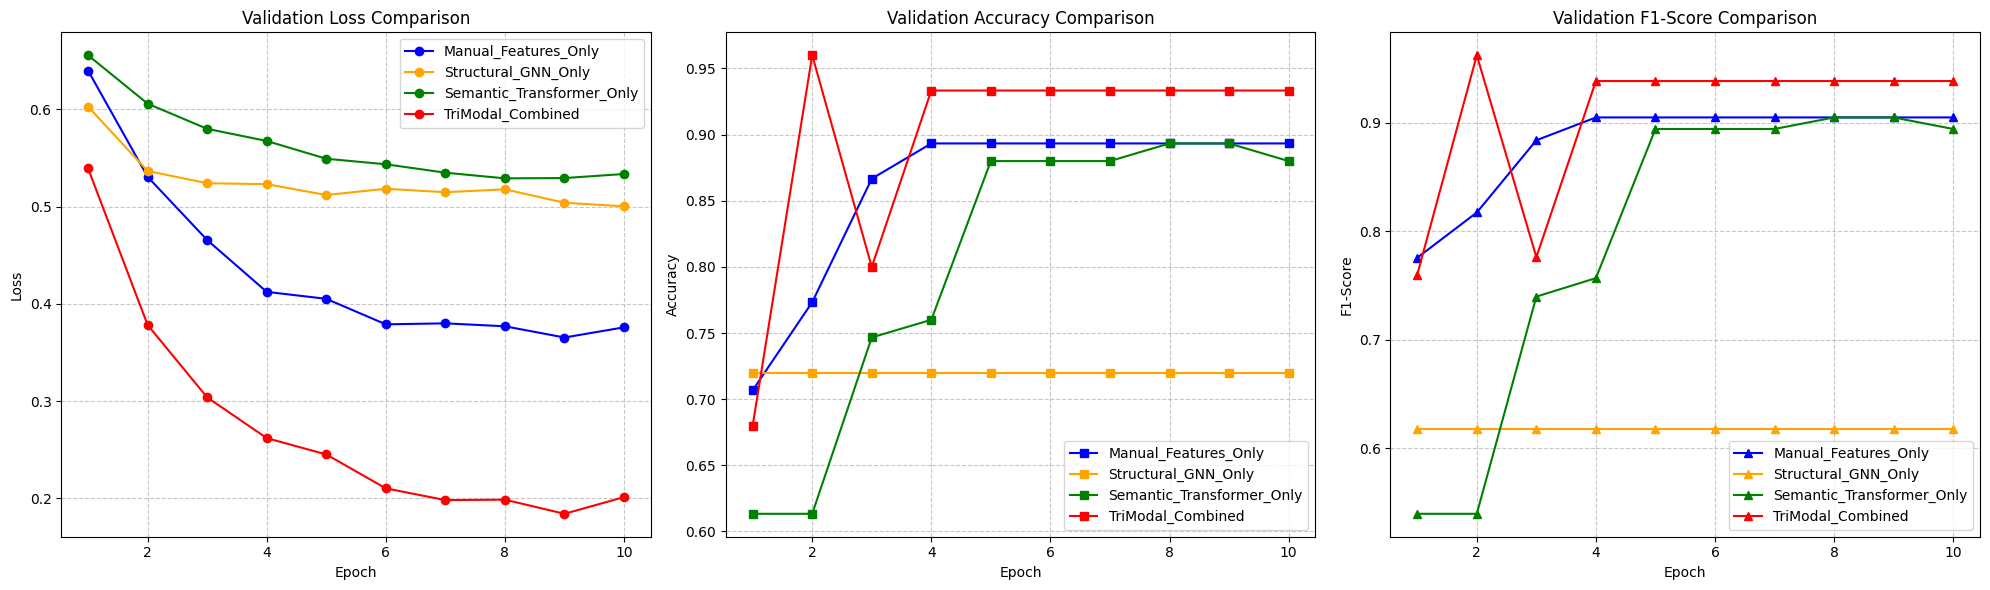

In [ ]:
import warnings
import matplotlib.pyplot as plt
from transformers import logging as hf_logging
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel

warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()


class ManualFeatureDetector(nn.Module):
    def __init__(self, manual_feat_dim, hidden_dim=64):
        super().__init__()
        self.feature_branch = nn.Sequential(
            nn.Linear(manual_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 2)
        )

    def forward(self, batch):
        feat_emb = self.feature_branch(batch.manual_features.view(batch.num_graphs, -1))
        return self.classifier(feat_emb)

class StructuralGNNDetector(nn.Module):
    def __init__(self, num_node_feat, gnn_hidden_dim):
        super().__init__()
        self.gnn_branch = StructuralGNN(num_node_features=num_node_feat, hidden_channels=gnn_hidden_dim)

        gnn_out_dim = gnn_hidden_dim * 2 
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(gnn_out_dim),
            nn.Linear(gnn_out_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 2)
        )

    def forward(self, batch):
        struct_emb = self.gnn_branch(batch.x, batch.edge_index, batch.batch)
        return self.classifier(struct_emb)

class SemanticTrojanDetector(nn.Module):
    def __init__(self, transformer_name="microsoft/codebert-base"):
        super().__init__()
        self.semantic_branch = AutoModel.from_pretrained(transformer_name)
        for param in self.semantic_branch.parameters():
            param.requires_grad = False

        codebert_out_dim = 768
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(codebert_out_dim),
            nn.Linear(codebert_out_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, batch):
        transformer_out = self.semantic_branch(
            batch.input_ids.view(batch.num_graphs, -1),
            batch.attention_mask.view(batch.num_graphs, -1)
        )
        sem_emb = transformer_out.last_hidden_state[:, 0, :]
        return self.classifier(sem_emb)




def train_standalone_model(model, model_name, train_loader, test_loader, device, num_epochs=10):
    print(f"\n🚀 Starting Training for: {model_name}")
    model = model.to(device)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-4,
        weight_decay=1e-3
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
    early_stopping = EarlyStopping(patience=5, path=f'best_{model_name}_model.pth')

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'val_f1': [], 'val_recall': []
    }

    for epoch in range(1, num_epochs + 1):
        train_metrics, val_metrics = train_and_evaluate(
            model, train_loader, test_loader, optimizer, criterion, device
        )
        scheduler.step()

        history['train_loss'].append(train_metrics['loss'])
        history['val_loss'].append(val_metrics['loss'])
        history['train_acc'].append(train_metrics['acc'])
        history['val_acc'].append(val_metrics['acc'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_recall'].append(val_metrics['recall'])

        print(f"Epoch {epoch:02d} | Train Loss: {train_metrics['loss']:.4f} | Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['acc']:.2%} | Val F1: {val_metrics['f1']:.4f}")

        early_stopping(val_metrics['loss'], model)
        if early_stopping.early_stop:
            print(f"🛑 Early stopping triggered at epoch {epoch}. Restoring best weights.")
            break

    model.load_state_dict(torch.load(f'best_{model_name}_model.pth', weights_only=True))
    print(f"✅ Finished {model_name}. Best weights loaded.")
    return history, model


NUM_MANUAL = 3
NUM_NODE_FEAT = 3
GNN_HIDDEN = 128
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

models_to_train = {
    "Manual_Features_Only": ManualFeatureDetector(NUM_MANUAL),
    "Structural_GNN_Only": StructuralGNNDetector(NUM_NODE_FEAT, GNN_HIDDEN),
    "Semantic_Transformer_Only": SemanticTrojanDetector("microsoft/codebert-base"),
    "TriModal_Combined": TriModalTrojanDetector(NUM_MANUAL, NUM_NODE_FEAT, GNN_HIDDEN)
}

histories = {}
trained_models = {}

for name, model in models_to_train.items():
    hist, trained_model = train_standalone_model(
        model, name, train_loader, test_loader, device, num_epochs=10
    )
    histories[name] = hist
    trained_models[name] = trained_model

print("\n📊 Generating Comparison Graphs...")

plt.figure(figsize=(20, 6))
colors = {'Manual_Features_Only': 'blue', 'Structural_GNN_Only': 'orange',
          'Semantic_Transformer_Only': 'green', 'TriModal_Combined': 'red'}

plt.subplot(1, 3, 1)
for name, hist in histories.items():
    plt.plot(range(1, len(hist['val_loss']) + 1), hist['val_loss'], marker='o', label=name, color=colors[name])
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 3, 2)
for name, hist in histories.items():
    plt.plot(range(1, len(hist['val_acc']) + 1), hist['val_acc'], marker='s', label=name, color=colors[name])
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 3, 3)
for name, hist in histories.items():
    plt.plot(range(1, len(hist['val_f1']) + 1), hist['val_f1'], marker='^', label=name, color=colors[name])
plt.title('Validation F1-Score Comparison')
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Extracting embeddings from TriModalTrojanDetector...
Original Embeddings Shape: (500, 1088)
Applying SMOTE to balance the dataset...
Balanced Embeddings Shape: (500, 1088)
Evaluating PCA dimensions with Shallow MLP (5-Fold CV)...


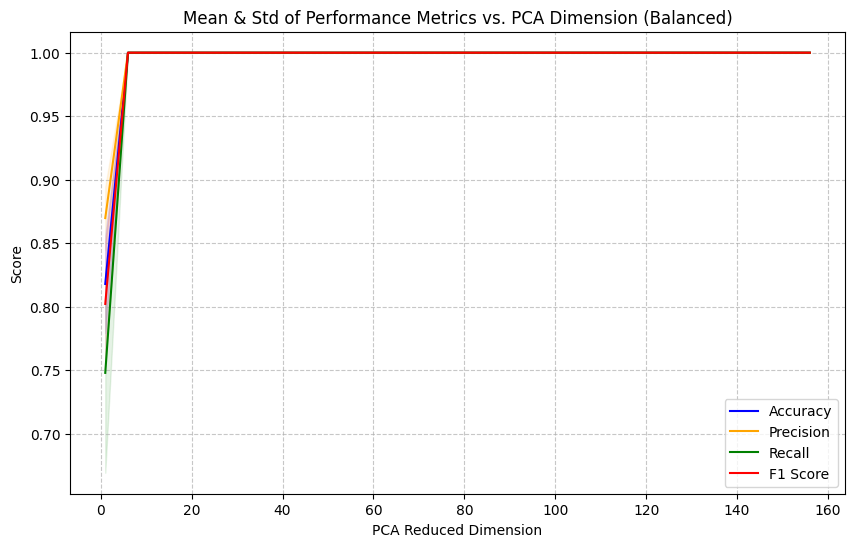

Generating Graph Embedding Visualizations...


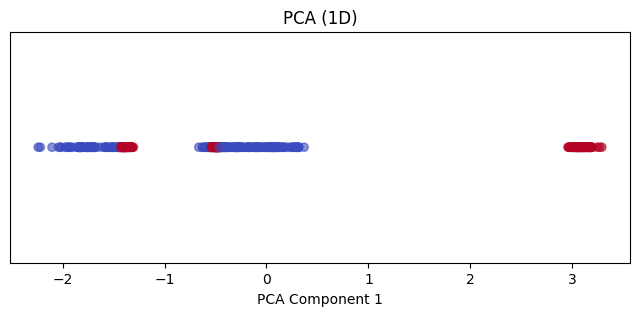

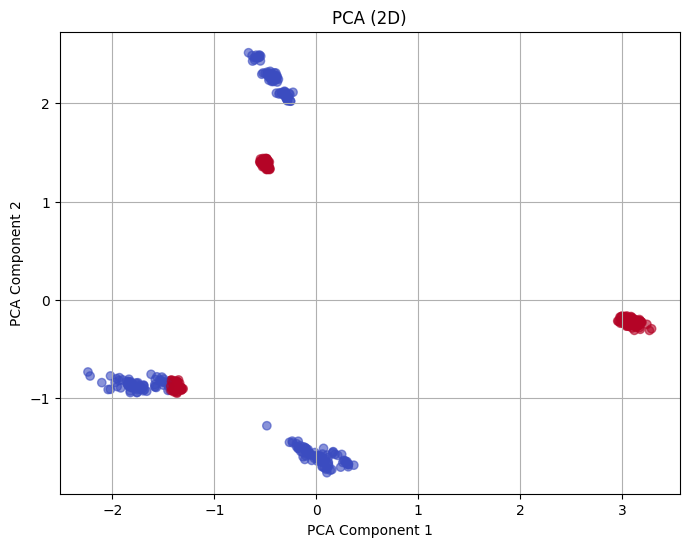

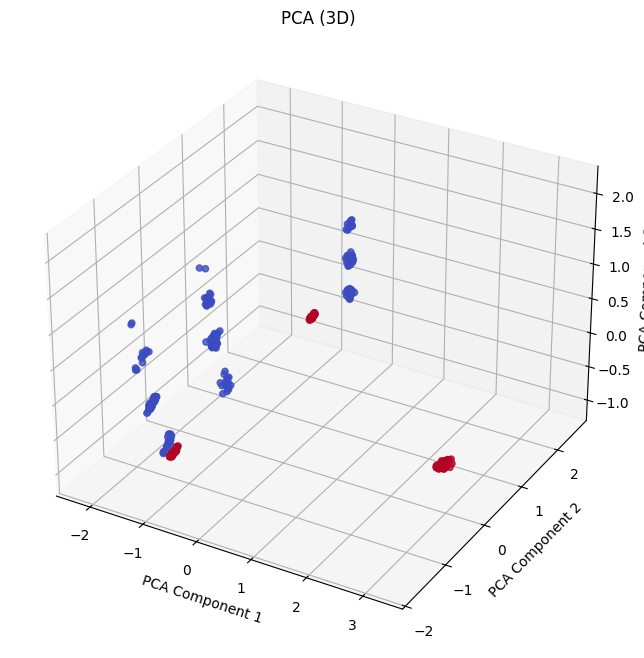

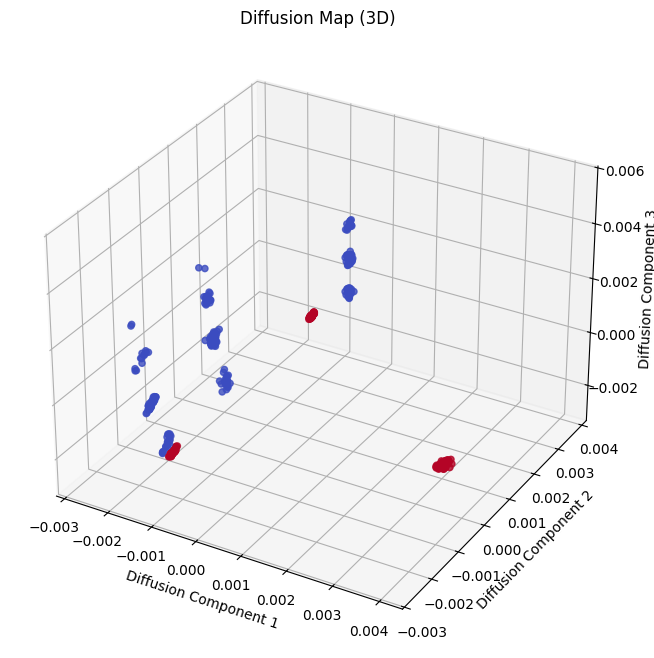

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import SpectralEmbedding
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch_geometric.loader import DataLoader
import torch


def get_trimodal_embeddings(trained_model, dataset, device):
    print("Extracting embeddings from TriModalTrojanDetector...")
    trained_model.eval()

    loader = DataLoader(dataset, batch_size=16, shuffle=False)

    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            feat_emb = trained_model.feature_branch(batch.manual_features.view(batch.num_graphs, -1))

            struct_emb = trained_model.gnn_branch(batch.x, batch.edge_index, batch.batch)

            transformer_out = trained_model.semantic_branch(
                batch.input_ids.view(batch.num_graphs, -1),
                batch.attention_mask.view(batch.num_graphs, -1)
            )

            sem_emb = transformer_out.last_hidden_state[:, 0, :]

            fused_vector = torch.cat([feat_emb, struct_emb, sem_emb], dim=1)

            all_embeddings.append(fused_vector.cpu().numpy())
            all_labels.append(batch.y.cpu().numpy())

    return np.vstack(all_embeddings), np.concatenate(all_labels)

X_emb, y_emb = get_trimodal_embeddings(model, dataset, device)
print(f"Original Embeddings Shape: {X_emb.shape}")


print("Applying SMOTE to balance the dataset...")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_emb, y_emb)
print(f"Balanced Embeddings Shape: {X_resampled.shape}")


max_dim = min(X_resampled.shape[0], X_resampled.shape[1], 160)
pca_dims = list(range(1, max_dim + 1, 5))

mean_acc, mean_prec, mean_rec, mean_f1 = [], [], [], []
std_acc, std_prec, std_rec, std_f1 = [], [], [], []

print("Evaluating PCA dimensions with Shallow MLP (5-Fold CV)...")
for d in pca_dims:
    pca = PCA(n_components=d)
    X_pca = pca.fit_transform(X_resampled)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accs, precs, recs, f1s = [], [], [], []

    for train_idx, test_idx in skf.split(X_pca, y_resampled):
        X_tr, X_te = X_pca[train_idx], X_pca[test_idx]
        y_tr, y_te = y_resampled[train_idx], y_resampled[test_idx]

        clf = MLPClassifier(hidden_layer_sizes=(64,), activation='relu', max_iter=500, random_state=42)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)

        accs.append(accuracy_score(y_te, preds))
        precs.append(precision_score(y_te, preds, zero_division=0))
        recs.append(recall_score(y_te, preds, zero_division=0))
        f1s.append(f1_score(y_te, preds, zero_division=0))

    mean_acc.append(np.mean(accs)); std_acc.append(np.std(accs))
    mean_prec.append(np.mean(precs)); std_prec.append(np.std(precs))
    mean_rec.append(np.mean(recs)); std_rec.append(np.std(recs))
    mean_f1.append(np.mean(f1s)); std_f1.append(np.std(f1s))

plt.figure(figsize=(10, 6))
plt.plot(pca_dims, mean_acc, label='Accuracy', color='blue')
plt.fill_between(pca_dims, np.array(mean_acc) - np.array(std_acc), np.array(mean_acc) + np.array(std_acc), alpha=0.1, color='blue')

plt.plot(pca_dims, mean_prec, label='Precision', color='orange')
plt.fill_between(pca_dims, np.array(mean_prec) - np.array(std_prec), np.array(mean_prec) + np.array(std_prec), alpha=0.1, color='orange')

plt.plot(pca_dims, mean_rec, label='Recall', color='green')
plt.fill_between(pca_dims, np.array(mean_rec) - np.array(std_rec), np.array(mean_rec) + np.array(std_rec), alpha=0.1, color='green')

plt.plot(pca_dims, mean_f1, label='F1 Score', color='red')
plt.fill_between(pca_dims, np.array(mean_f1) - np.array(std_f1), np.array(mean_f1) + np.array(std_f1), alpha=0.1, color='red')

plt.title('Mean & Std of Performance Metrics vs. PCA Dimension (Balanced)')
plt.xlabel('PCA Reduced Dimension')
plt.ylabel('Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Generating Graph Embedding Visualizations...")

pca_1d = PCA(n_components=1)
X_1d = pca_1d.fit_transform(X_resampled)

plt.figure(figsize=(8, 3))
plt.scatter(X_1d, np.zeros_like(X_1d), c=y_resampled, cmap='coolwarm', alpha=0.6)
plt.title('PCA (1D)')
plt.xlabel('PCA Component 1')
plt.yticks([])
plt.show()

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_resampled)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_resampled, cmap='coolwarm', alpha=0.6)
plt.title('PCA (2D)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()

pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_resampled)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y_resampled, cmap='coolwarm', alpha=0.8)
ax.set_title('PCA (3D)')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
plt.show()

se_3d = SpectralEmbedding(n_components=3, affinity='rbf', random_state=42)
X_diff = se_3d.fit_transform(X_resampled)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_diff[:, 0], X_diff[:, 1], X_diff[:, 2], c=y_resampled, cmap='coolwarm', alpha=0.8)
ax.set_title('Diffusion Map (3D)')
ax.set_xlabel('Diffusion Component 1')
ax.set_ylabel('Diffusion Component 2')
ax.set_zlabel('Diffusion Component 3')
plt.show()